# Importing Specific Libraries Used in this Project

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Reading the Dataset from the File Path

Use the Pandas method <b>read_csv()</b> to load the data from the file path

In [3]:
import pandas as pd

# Read the data
df = pd.read_csv('Customers.csv')

In [4]:
filename = 'Customers.csv'
filename

'Customers.csv'

 Using the method <b>head()</b> to display the first five rows of the dataframe. 


In [5]:
# To see what the data set looks like, we'll use the head() method.
df.head()

,CustomerID,Gender,Age,Annual Income ($),Spending Score (1-100),Profession,Work Experience,Family Size
0,1,Male,19,15000,39,Healthcare,1,4
1,2,Male,21,35000,81,Engineer,3,3
2,3,Female,20,86000,6,Engineer,1,1
3,4,Female,23,59000,77,Lawyer,0,2
4,5,Female,31,38000,40,Entertainment,2,6


 Use the method <b>info()</b> to display the summary of the dataframe, especially checking for null values


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              2000 non-null   int64 
 1   Gender                  2000 non-null   object
 2   Age                     2000 non-null   int64 
 3   Annual Income ($)       2000 non-null   int64 
 4   Spending Score (1-100)  2000 non-null   int64 
 5   Profession              1965 non-null   object
 6   Work Experience         2000 non-null   int64 
 7   Family Size             2000 non-null   int64 
dtypes: int64(6), object(2)
memory usage: 109.4+ KB


<h4>Evaluating for Missing Data</h4>

The missing values are converted by default. Using the following functions to identify these missing values. We can use two methods to detect missing data:
<ol>
    <li><b>.isnull()</b></li>
    <li><b>.notnull()</b></li>
</ol>
The output is a boolean value indicating whether the value that is passed into the argument is in fact missing data.

In [7]:
missing_data = df.isnull()
missing_data.head(5)

,CustomerID,Gender,Age,Annual Income ($),Spending Score (1-100),Profession,Work Experience,Family Size
0,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False


"True" means the value is a missing value while "False" means the value is not a missing value.


<h4>Counting missing values in each column</h4>
<p>
Using a for loop in Python, we can quickly figure out the number of missing values in each column. As mentioned above, "True" represents a missing value and "False" means the value is present in the data set.  In the body of the for loop the method ".value_counts()" counts the number of "True" values. 
</p>

In [8]:
for column in missing_data.columns.values.tolist():
    print(column)
    print (missing_data[column].value_counts())
    print("")

CustomerID
CustomerID
False    2000
Name: count, dtype: int64

Gender
Gender
False    2000
Name: count, dtype: int64

Age
Age
False    2000
Name: count, dtype: int64

Annual Income ($)
Annual Income ($)
False    2000
Name: count, dtype: int64

Spending Score (1-100)
Spending Score (1-100)
False    2000
Name: count, dtype: int64

Profession
Profession
False    1965
True       35
Name: count, dtype: int64

Work Experience
Work Experience
False    2000
Name: count, dtype: int64

Family Size
Family Size
False    2000
Name: count, dtype: int64



To see which values are present in a particular column, we can use the ".value_counts()" method:


In [9]:
df['Profession'].value_counts()

Profession
Artist           612
Healthcare       339
Entertainment    234
Engineer         179
Doctor           161
Executive        153
Lawyer           142
Marketing         85
Homemaker         60
Name: count, dtype: int64

We can see that Artist is the most common type. We can also use the ".idxmax()" method to calculate the most common type automatically:


In [10]:
df['Profession'].value_counts().idxmax()

'Artist'

The replacement procedure is very similar to what we have seen previously:


In [ ]:
#replace the missing 'num-of-doors' values by the most frequent 
df["Profession"].replace(np.nan, "Artist", inplace=True)

In [12]:
df.head()

,CustomerID,Gender,Age,Annual Income ($),Spending Score (1-100),Profession,Work Experience,Family Size
0,1,Male,19,15000,39,Healthcare,1,4
1,2,Male,21,35000,81,Engineer,3,3
2,3,Female,20,86000,6,Engineer,1,1
3,4,Female,23,59000,77,Lawyer,0,2
4,5,Female,31,38000,40,Entertainment,2,6


<b>Good!</b> Now, we have a data set with no missing values.


<h3 id="correct_data_format">Correct data format</h3>
<b>We are almost there!</b>
<p>The last step in data cleaning is checking and making sure that all data is in the correct format (int, float, text or other).</p>

In Pandas, you use:
<p><b>.dtype()</b> to check the data type</p>
<p><b>.astype()</b> to change the data type</p>

<h4>Let's list the data types for each column</h4>


In [13]:
df.dtypes

CustomerID                 int64
Gender                    object
Age                        int64
Annual Income ($)          int64
Spending Score (1-100)     int64
Profession                object
Work Experience            int64
Family Size                int64
dtype: object

We can see above that, all columns are in correct data format

Let's normalize and scale the following columns 'Age', 'Work Experience', 'Family Size', 'Annual Income ($)'
For example, when working with the variables length, width, and height, the target is to normalize them so their values range between 0 and 1. The approach involves replacing each original value with the ratio of that value to the maximum observed value.

In [14]:
# replace (original value) by (original value)/(maximum value)
df['Age'] = df['Age']/df['Age'].max()
df['Work Experience'] = df['Work Experience']/df['Work Experience'].max()
df['Family Size'] = df['Family Size']/df['Family Size'].max()
df['Annual Income ($)'] = df['Annual Income ($)']/df['Annual Income ($)'].max()
df[['Age', 'Work Experience', 'Family Size', 'Annual Income ($)']].head()

,Age,Work Experience,Family Size,Annual Income ($)
0,0.191919,0.058824,0.444444,0.078958
1,0.212121,0.176471,0.333333,0.184236
2,0.202020,0.058824,0.111111,0.452694
3,0.232323,0.000000,0.222222,0.310569
4,0.313131,0.117647,0.666667,0.200027


Plot the histogram of horsepower to see the distribution of horsepower.


Text(0.5, 1.0, 'Annual Income ($) bins')

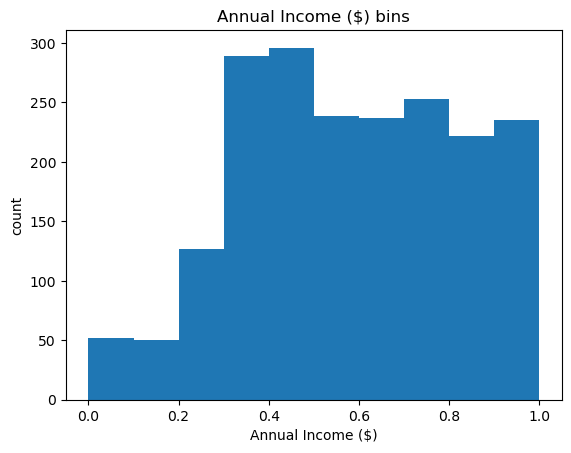

In [15]:
%matplotlib inline
import matplotlib as plt
from matplotlib import pyplot
plt.pyplot.hist(df["Annual Income ($)"])

# set x/y labels and plot title
plt.pyplot.xlabel("Annual Income ($)")
plt.pyplot.ylabel("count")
plt.pyplot.title("Annual Income ($) bins")

<p>Finding 3 bins of equal size bandwidth by using Numpy's <code>linspace(start_value, end_value, numbers_generated</code> function.</p>
<p>Since we want to include the minimum value of horsepower, set start_value = min(df["Annual Income"]).</p>
<p>Since we want to include the maximum value of horsepower, set end_value = max(df["Annual Income"]).</p>
<p>Since we are building 3 bins of equal length, you need 4 dividers, so numbers_generated = 4.</p>


Building a bin array with a minimum value to a maximum value by using the bandwidth calculated above. The values will determine when one bin ends and another begins.

In [16]:
bins = np.linspace(min(df["Annual Income ($)"]), max(df["Annual Income ($)"]), 4)
bins

array([0.        , 0.33333333, 0.66666667, 1.        ])

Setting group names

In [17]:
group_names = ['Low', 'Medium', 'High']

Applying the function "cut" to determine what each value of `df['Annual Income ($)']` belongs to. 


In [18]:
df['Annual Income ($)-binned'] = pd.cut(df['Annual Income ($)'], bins, labels=group_names, include_lowest=True )
df[['Annual Income ($)','Annual Income ($)-binned']].head(20)

,Annual Income ($),Annual Income ($)-binned
0,0.078958,Low
1,0.184236,Low
2,0.452694,Medium
3,0.310569,Low
4,0.200027,Low
5,0.305305,Low
6,0.163180,Low
7,0.442166,Medium
8,0.510596,Medium
9,0.515860,Medium


See the number of vehicles in each bin:


In [19]:
df["Annual Income ($)-binned"].value_counts()

Annual Income ($)-binned
Medium    889
High      786
Low       325
Name: count, dtype: int64

Ploting the distribution of each bin:


Text(0.5, 1.0, 'Annual Income ($) bins')

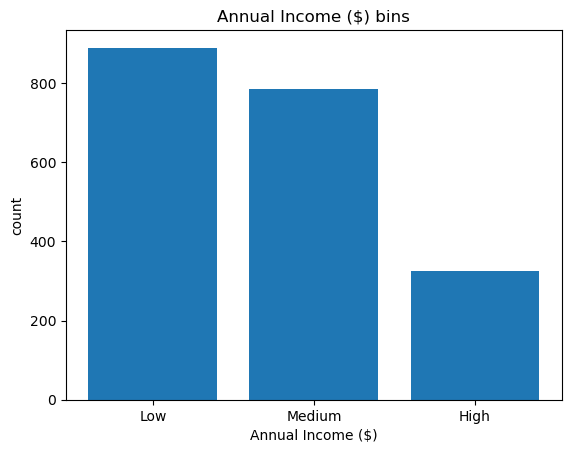

In [20]:
%matplotlib inline
import matplotlib as plt
from matplotlib import pyplot
pyplot.bar(group_names, df["Annual Income ($)-binned"].value_counts())

# set x/y labels and plot title
plt.pyplot.xlabel("Annual Income ($)")
plt.pyplot.ylabel("count")
plt.pyplot.title("Annual Income ($) bins")

<p>
    Look at the data frame above carefully. You will find that the last column provides the bins for "horsepower" based on 3 categories ("Low", "Medium" and "High"). 
</p>

Normally, we use a histogram to visualize the distribution of bins we created above. 

Text(0.5, 1.0, 'Annual Income ($) bins')

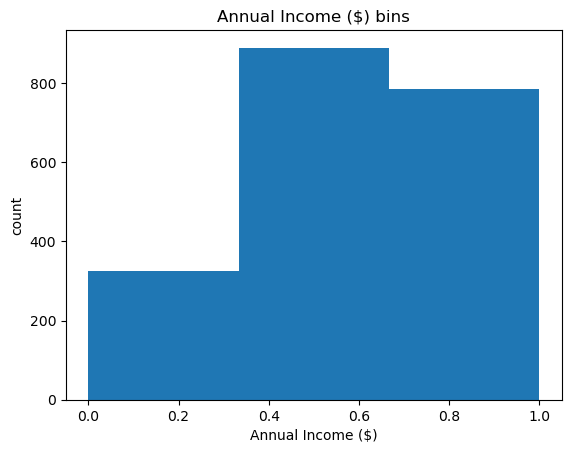

In [21]:
%matplotlib inline
import matplotlib as plt
from matplotlib import pyplot


# draw historgram of attribute "Annual Income ($)" with bins = 3
plt.pyplot.hist(df["Annual Income ($)"], bins = 3)

# set x/y labels and plot title
plt.pyplot.xlabel("Annual Income ($)")
plt.pyplot.ylabel("count")
plt.pyplot.title("Annual Income ($) bins")

The plot above shows the binning result for the attribute "Annual Income ($)". 


Let's add indicator variable (dummy variable)
We use indicator variables so we can use categorical variables for regression analysis in the later projects.
<b>Example</b>
<p>
    The column "Gender" has two unique values: "Male" or "Female". Regression doesn't understand words, only numbers. To use this attribute in regression analysis, you can convert "fuel-type" to indicator variables.
</p>

<p>
    Using the Panda method 'get_dummies' to assign numerical values to different categories of Gender. 
</p>

In [22]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income ($)',
       'Spending Score (1-100)', 'Profession', 'Work Experience',
       'Family Size', 'Annual Income ($)-binned'],
      dtype='object')

Getting the indicator variables and assign it to data frame "dummy_variable_1":

In [23]:
dummy_variable_1 = pd.get_dummies(df["Gender"])
dummy_variable_1.head()

,Female,Male
0,False,True
1,False,True
2,True,False
3,True,False
4,True,False


# Saving the clean dataset

In [24]:
df.to_csv('clean_df.csv')